In [1]:
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer

In [2]:
dataset = load_dataset("imdb")

In [6]:
dataset.keys()

dict_keys(['train', 'test', 'unsupervised'])

In [11]:
for i in range(10):
    print(dataset["train"][i])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [12]:
print(dataset["train"].features["label"])

ClassLabel(names=['neg', 'pos'])


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("imdb")

# Convert splits to DataFrames for easy EDA
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

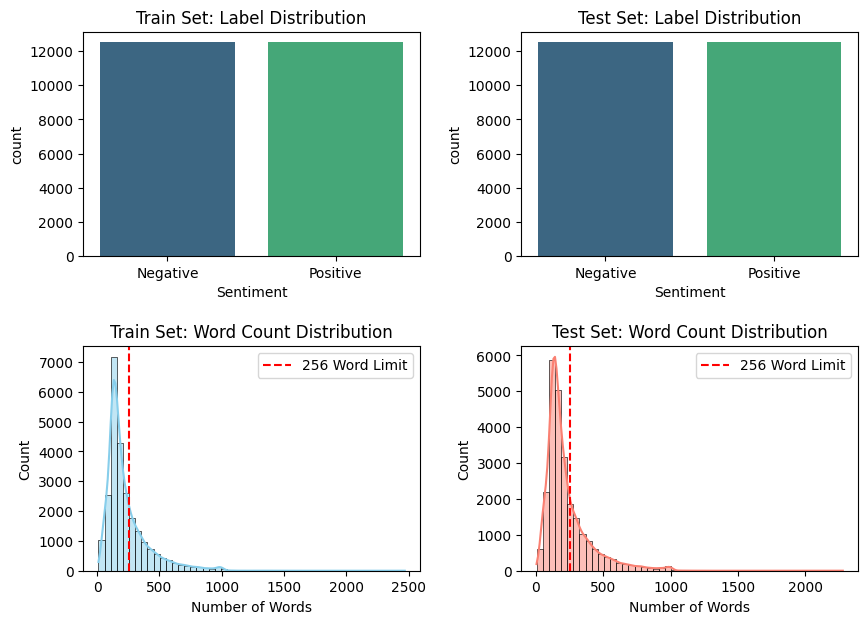

In [36]:
# Calculate text lengths (word count)
train_df["word_count"] = train_df["text"].str.split().str.len()
test_df["word_count"] = test_df["text"].str.split().str.len()

# Create the Plotting Canvas
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

label_map = {0: "Negative", 1: "Positive"}

# Train Labels
sns.countplot(
    x=train_df["label"].map(label_map),
    hue=train_df["label"].map(label_map),
    ax=axes[0, 0],
    palette="viridis",
    legend=False,
)
axes[0, 0].set_title("Train Set: Label Distribution")
axes[0, 0].set_xlabel("Sentiment")

# Test Labels
sns.countplot(
    x=test_df["label"].map(label_map),
    hue=test_df["label"].map(label_map),
    ax=axes[0, 1],
    palette="viridis",
    legend=False,
)
axes[0, 1].set_title("Test Set: Label Distribution")
axes[0, 1].set_xlabel("Sentiment")


# Train Lengths
sns.histplot(train_df["word_count"], bins=50, ax=axes[1, 0], color="skyblue", kde=True)
axes[1, 0].axvline(256, color="red", linestyle="--", label="256 Word Limit")
axes[1, 0].set_title("Train Set: Word Count Distribution")
axes[1, 0].set_xlabel("Number of Words")
axes[1, 0].legend()

# Test Lengths
sns.histplot(test_df["word_count"], bins=50, ax=axes[1, 1], color="salmon", kde=True)
axes[1, 1].axvline(256, color="red", linestyle="--", label="256 Word Limit")
axes[1, 1].set_title("Test Set: Word Count Distribution")
axes[1, 1].set_xlabel("Number of Words")
axes[1, 1].legend()

plt.show()

In [37]:
# 5. Print Numerical Summaries
print("--- Training Set Stats ---")
print(train_df["label"].value_counts())
print(train_df["word_count"].describe())

print("\n--- Test Set Stats ---")
print(test_df["label"].value_counts())
print(test_df["word_count"].describe())

--- Training Set Stats ---
label
0    12500
1    12500
Name: count, dtype: int64
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64

--- Test Set Stats ---
label
0    12500
1    12500
Name: count, dtype: int64
count    25000.000000
mean       228.526680
std        168.883693
min          4.000000
25%        126.000000
50%        172.000000
75%        277.000000
max       2278.000000
Name: word_count, dtype: float64
